In [1]:
# KÜTÜPHANELERİN İÇE AKTARILMASI VERİ KONTROLÜ


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

svetlana = pd.read_csv("Svetlana-cardio_train.csv", sep=";")
alex = pd.read_csv("Alex-heart_disease_health_indicators_BRFSS2015.csv")

print("=== SVETLANA ===")
print(f"Boyut: {svetlana.shape}")
print(svetlana.head(3))

print("\n=== ALEX ===")
print(f"Boyut: {alex.shape}")
print(alex.head(3))

=== SVETLANA ===
Boyut: (70000, 13)
   id    age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  \
0   0  18393       2     168    62.0    110     80            1     1      0   
1   1  20228       1     156    85.0    140     90            3     1      0   
2   2  18857       1     165    64.0    130     70            3     1      0   

   alco  active  cardio  
0     0       1       0  
1     0       1       1  
2     0       0       1  

=== ALEX ===
Boyut: (253680, 22)
   HeartDiseaseorAttack  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0                   0.0     1.0       1.0        1.0  40.0     1.0     0.0   
1                   0.0     0.0       0.0        0.0  25.0     1.0     0.0   
2                   0.0     1.0       1.0        1.0  28.0     0.0     0.0   

   Diabetes  PhysActivity  Fruits  ...  AnyHealthcare  NoDocbcCost  GenHlth  \
0       0.0           0.0     0.0  ...            1.0          0.0      5.0   
1       0.0           1.0     0.0 

In [2]:
# STEVLANA VERİ DÜZENLEME
    #ID sütunu silindi.
    #Yaş göstergesi günden yıla çevrildi.
    #Boy ve kilo bilgisi kullanılarak Vücut Kitle İndeksi(BMI) hesaplandı.
    #Boy, kilo, tansiyon, glukoz gibi Alex veri ile çakışan sütunlar silindi.
    #Sütun isimleri Alex veri seti ile ortak hale getirildi. 


svetlana = svetlana.drop(columns=["id"])

svetlana["age"] = (svetlana["age"] / 365).astype(int)

svetlana["bmi"] = (svetlana["weight"] / (svetlana["height"] / 100) ** 2).round(1)

svetlana = svetlana.drop(columns=["height", "weight", "ap_lo", "gluc"])

svetlana = svetlana.rename(columns={
    "ap_hi"       : "blood_pressure",
    "smoke"       : "smoking",
    "alco"        : "alcohol",
    "cardio"      : "heart_disease"
})

svetlana["source"] = "svetlana"

print("Svetlana hazır!")
print(svetlana.shape)
print(svetlana.head(3))

Svetlana hazır!
(70000, 10)
   age  gender  blood_pressure  cholesterol  smoking  alcohol  active  \
0   50       2             110            1        0        0       1   
1   55       1             140            3        0        0       1   
2   51       1             130            3        0        0       0   

   heart_disease   bmi    source  
0              0  22.0  svetlana  
1              1  34.9  svetlana  
2              1  23.5  svetlana  


In [3]:
# ALEX VERİ DÜZENLEME
    #Svetlana veri setinde olmayan sütunlar silindi.
    #Sütun isimleri Svetlana veri seti ile ortak hale getirildi.


alex_temiz = alex[[
    "Age", "Sex", "HighBP", "HighChol",
    "Smoker", "HvyAlcoholConsump", "PhysActivity",
    "BMI", "HeartDiseaseorAttack"
]].copy()

alex_temiz = alex_temiz.rename(columns={
    "Age"                : "age",
    "Sex"                : "gender",
    "HighBP"             : "blood_pressure",
    "HighChol"           : "cholesterol",
    "Smoker"             : "smoking",
    "HvyAlcoholConsump"  : "alcohol",
    "PhysActivity"       : "active",
    "BMI"                : "bmi",
    "HeartDiseaseorAttack": "heart_disease"
})

alex_temiz["source"] = "alex"

print("Alex hazır!")
print(alex_temiz.shape)
print(alex_temiz.head(3))

Alex hazır!
(253680, 10)
   age  gender  blood_pressure  cholesterol  smoking  alcohol  active   bmi  \
0  9.0     0.0             1.0          1.0      1.0      0.0     0.0  40.0   
1  7.0     0.0             0.0          0.0      1.0      0.0     1.0  25.0   
2  9.0     0.0             1.0          1.0      0.0      0.0     0.0  28.0   

   heart_disease source  
0            0.0   alex  
1            0.0   alex  
2            0.0   alex  


In [4]:
# VERİLERİN ORTAK HALE GETİRİLMESİ
    #Alex yaş göstergesi yıllık yerine kategorik olarak 5 yıllık aralıklarla oluşturulmuş.
        #Bunu düzeltmek için katagorik yaş aralıklarını yıllık yaşların ortalamasıyla eşleştirildi.
    #Alex cinsiyet göstergesi Svetlana veri setiyle uyumlu hale getirildi(1=kadın, 2=erkek).
    #Svetlana veri setindeki tansiyon ve kolesterol göstergeleri binary'e çevrildi.


yas_map = {
    1: 21, 2: 27, 3: 32, 4: 37, 5: 42,
    6: 47, 7: 52, 8: 57, 9: 62, 10: 67,
    11: 72, 12: 77, 13: 82
}
alex_temiz["age"] = alex_temiz["age"].map(yas_map)

alex_temiz["gender"] = alex_temiz["gender"].map({0: 1, 1: 2})

svetlana["blood_pressure"] = (svetlana["blood_pressure"] >= 130).astype(int)

svetlana["cholesterol"] = (svetlana["cholesterol"] > 1).astype(int)

print("Alex NaN sayısı:", alex_temiz.isnull().sum().sum())
print("Svetlana NaN sayısı:", svetlana.isnull().sum().sum())

print("\nAlex örnek:")
print(alex_temiz.head(3))
print("\nSvetlana örnek:")
print(svetlana.head(3))


Alex NaN sayısı: 0
Svetlana NaN sayısı: 0

Alex örnek:
   age  gender  blood_pressure  cholesterol  smoking  alcohol  active   bmi  \
0   62       1             1.0          1.0      1.0      0.0     0.0  40.0   
1   52       1             0.0          0.0      1.0      0.0     1.0  25.0   
2   62       1             1.0          1.0      0.0      0.0     0.0  28.0   

   heart_disease source  
0            0.0   alex  
1            0.0   alex  
2            0.0   alex  

Svetlana örnek:
   age  gender  blood_pressure  cholesterol  smoking  alcohol  active  \
0   50       2               0            0        0        0       1   
1   55       1               1            1        0        0       1   
2   51       1               1            1        0        0       0   

   heart_disease   bmi    source  
0              0  22.0  svetlana  
1              1  34.9  svetlana  
2              1  23.5  svetlana  


In [5]:
# VERİ SETLERİNİ BİRLEŞTİRME
    #Veri setler birleştirildi.
    #Veri tipleri düzeltildi.

    
df = pd.concat([svetlana, alex_temiz], ignore_index=True)

df = df.astype({
    "age"            : int,
    "gender"         : int,
    "blood_pressure" : int,
    "cholesterol"    : int,
    "smoking"        : int,
    "alcohol"        : int,
    "active"         : int,
    "bmi"            : float,
    "heart_disease"  : int
})

print("=== BİRLEŞİK DATASET ===")
print(f"Toplam satır: {df.shape[0]}")
print(f"Toplam sütun: {df.shape[1]}")
print(f"\nKaynak dağılımı:")
print(df["source"].value_counts())
print(f"\nHedef değişken dağılımı:")
print(df["heart_disease"].value_counts())
print(f"\nİlk 3 satır:")
print(df.head(3))

=== BİRLEŞİK DATASET ===
Toplam satır: 323680
Toplam sütun: 10

Kaynak dağılımı:
source
alex        253680
svetlana     70000
Name: count, dtype: int64

Hedef değişken dağılımı:
heart_disease
0    264808
1     58872
Name: count, dtype: int64

İlk 3 satır:
   age  gender  blood_pressure  cholesterol  smoking  alcohol  active  \
0   50       2               0            0        0        0       1   
1   55       1               1            1        0        0       1   
2   51       1               1            1        0        0       0   

   heart_disease   bmi    source  
0              0  22.0  svetlana  
1              1  34.9  svetlana  
2              1  23.5  svetlana  


In [6]:
# BİRLEŞİK DATASETİNİN KAYDEDİLMESİ  


df.to_csv("combined_heart_disease.csv", index=False)
print("Dataset kaydedildi ✅")
print(f"Dosya boyutu: {df.memory_usage(deep=True).sum() / 1024 / 1024:.1f} MB")

Dataset kaydedildi ✅
Dosya boyutu: 38.9 MB


In [7]:
# GENEL KONTROL


print("=== TEMEL İSTATİSTİKLER ===")
print(df.describe())

print("\n=== KALP HASTALIĞI ORANI ===")
toplam = len(df)
hasta = df["heart_disease"].sum()
saglikli = toplam - hasta
print(f"Hasta    : {hasta:,} ({hasta/toplam*100:.1f}%)")
print(f"Sağlıklı : {saglikli:,} ({saglikli/toplam*100:.1f}%)")

=== TEMEL İSTATİSTİKLER ===
                 age         gender  blood_pressure    cholesterol  \
count  323680.000000  323680.000000   323680.000000  323680.000000   
mean       56.208746       1.420712        0.424812       0.386820   
std        14.037830       0.493674        0.494315       0.487023   
min        21.000000       1.000000        0.000000       0.000000   
25%        47.000000       1.000000        0.000000       0.000000   
50%        57.000000       1.000000        0.000000       0.000000   
75%        67.000000       2.000000        1.000000       1.000000   
max        82.000000       2.000000        1.000000       1.000000   

             smoking        alcohol         active  heart_disease  \
count  323680.000000  323680.000000  323680.000000  323680.000000   
mean        0.366387       0.055672       0.766748       0.181883   
std         0.481818       0.229288       0.422902       0.385749   
min         0.000000       0.000000       0.000000       0.000000

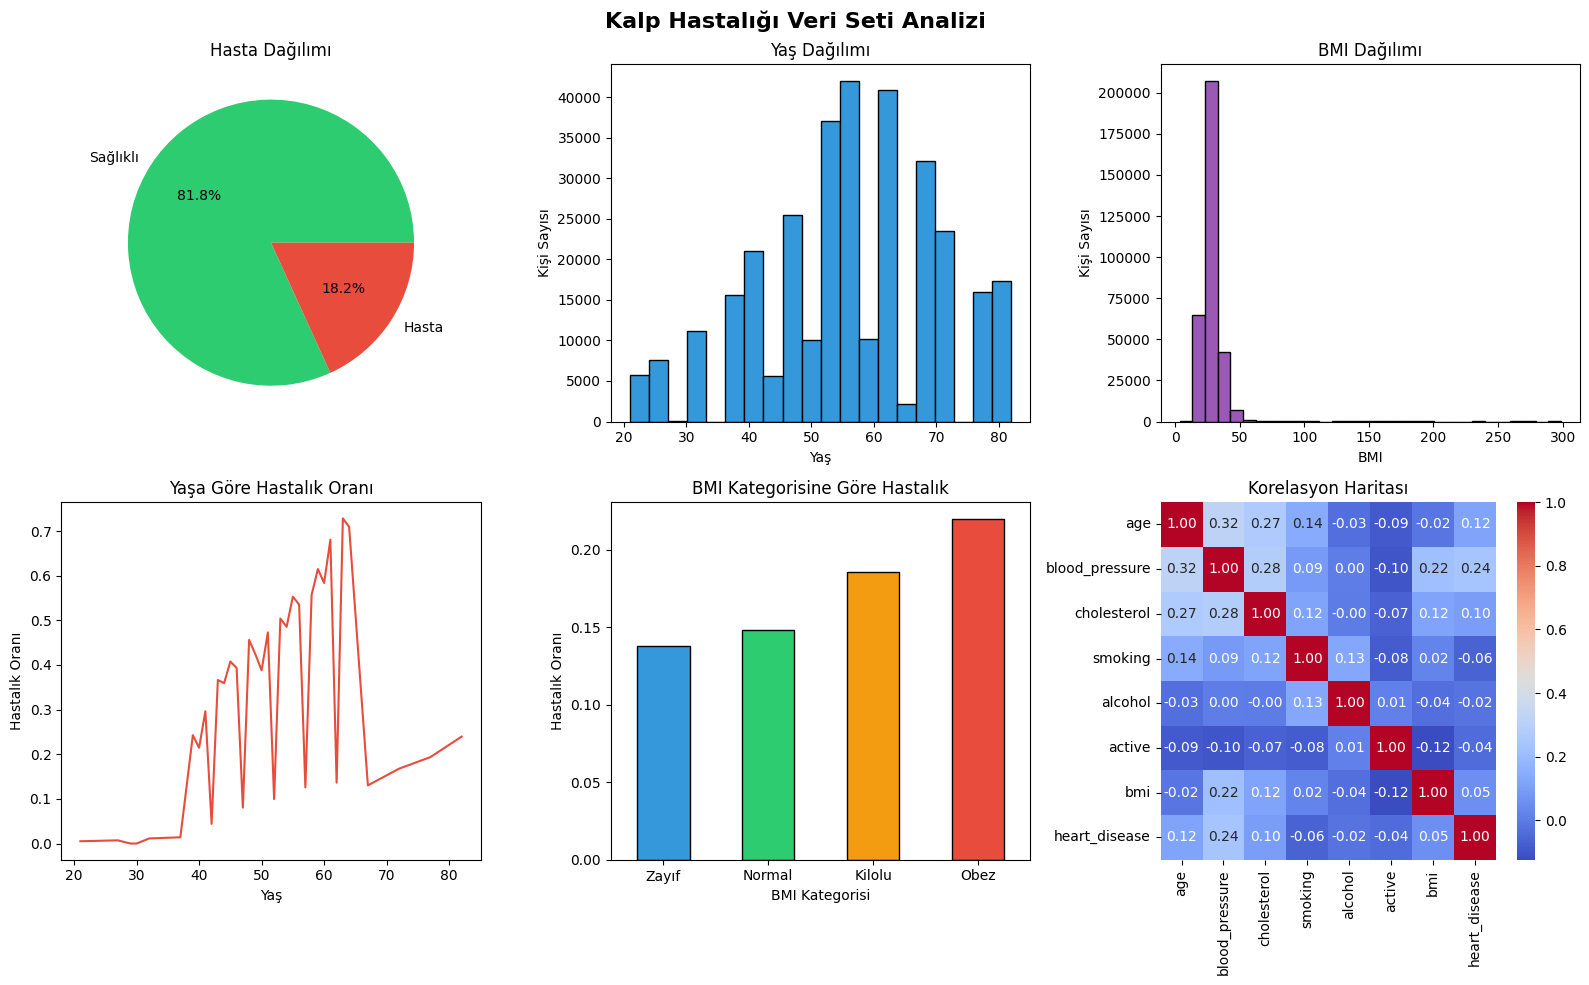

Grafikler kaydedildi ✅


In [8]:
# ANALİZ VE GRAFİKLER


fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Kalp Hastalığı Veri Seti Analizi", fontsize=16, fontweight="bold")

# 1. Hasta dağılımı
axes[0,0].pie([264808, 58872], labels=["Sağlıklı", "Hasta"],
              autopct="%1.1f%%", colors=["#2ecc71", "#e74c3c"])
axes[0,0].set_title("Hasta Dağılımı")

# 2. Yaş dağılımı
axes[0,1].hist(df["age"], bins=20, color="#3498db", edgecolor="black")
axes[0,1].set_title("Yaş Dağılımı")
axes[0,1].set_xlabel("Yaş")
axes[0,1].set_ylabel("Kişi Sayısı")

# 3. BMI dağılımı
axes[0,2].hist(df["bmi"], bins=30, color="#9b59b6", edgecolor="black")
axes[0,2].set_title("BMI Dağılımı")
axes[0,2].set_xlabel("BMI")
axes[0,2].set_ylabel("Kişi Sayısı")

# 4. Yaşa göre kalp hastalığı
df.groupby("age")["heart_disease"].mean().plot(ax=axes[1,0], color="#e74c3c")
axes[1,0].set_title("Yaşa Göre Hastalık Oranı")
axes[1,0].set_xlabel("Yaş")
axes[1,0].set_ylabel("Hastalık Oranı")

# 5. BMI kategorisine göre hastalık
df["bmi_kategori"] = pd.cut(df["bmi"], 
                             bins=[0, 18.5, 25, 30, 100],
                             labels=["Zayıf", "Normal", "Kilolu", "Obez"])
df.groupby("bmi_kategori", observed=True)["heart_disease"].mean().plot(
    kind="bar", ax=axes[1,1], color=["#3498db","#2ecc71","#f39c12","#e74c3c"],
    edgecolor="black")
axes[1,1].set_title("BMI Kategorisine Göre Hastalık")
axes[1,1].set_xlabel("BMI Kategorisi")
axes[1,1].set_ylabel("Hastalık Oranı")
axes[1,1].tick_params(axis="x", rotation=0)

# 6. Korelasyon haritası
numeric_cols = ["age","blood_pressure","cholesterol","smoking",
                "alcohol","active","bmi","heart_disease"]
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", 
            cmap="coolwarm", ax=axes[1,2])
axes[1,2].set_title("Korelasyon Haritası")

plt.tight_layout()
plt.savefig("analiz_grafikleri.png", dpi=150, bbox_inches="tight")
plt.show()
print("Grafikler kaydedildi ✅")

In [9]:
# AYKIRI DEĞER ANALİZİ VE TEMİZLEME
    #BMI değerlerindeki aşırı uçuşlar temizlendi.


print("=== AYKIRI BMI DEĞERLERİ ===")
print(f"BMI > 60 olan satır sayısı: {(df['bmi'] > 60).sum()}")
print(f"BMI < 10 olan satır sayısı: {(df['bmi'] < 10).sum()}")

# BMI aykırı değerleri temizle (gerçekçi aralık: 10-60)
df = df[(df["bmi"] >= 10) & (df["bmi"] <= 60)]

print(f"\nTemizleme sonrası satır sayısı: {len(df):,}")
print(f"Silinen satır sayısı: {323680 - len(df):,}")

=== AYKIRI BMI DEĞERLERİ ===
BMI > 60 olan satır sayısı: 870
BMI < 10 olan satır sayısı: 6

Temizleme sonrası satır sayısı: 322,804
Silinen satır sayısı: 876


In [10]:
# TEMİZ DATASET KAYDEDİLMESİ


df.to_csv("combined_heart_disease.csv", index=False)
print(f"Temiz dataset kaydedildi ✅")
print(f"Final boyut: {df.shape}")

Temiz dataset kaydedildi ✅
Final boyut: (322804, 11)


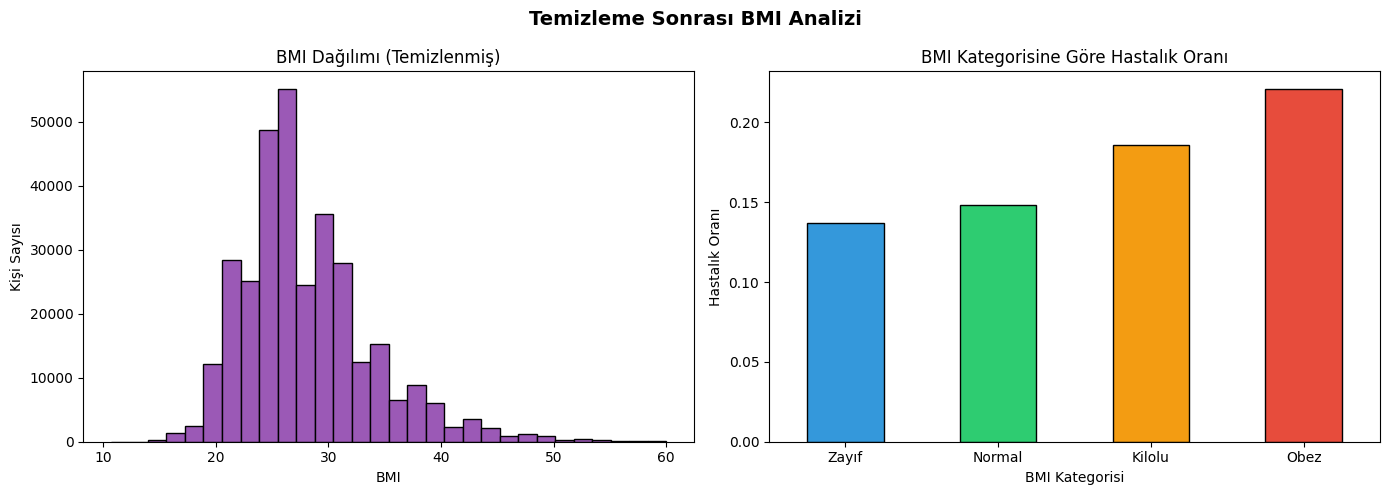

BMI grafikleri kaydedildi ✅


In [11]:
# TEMİZLENMİŞ DATASET İLE ANALİZ VE GRAFİKLER


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Temizleme Sonrası BMI Analizi", fontsize=14, fontweight="bold")

# BMI dağılımı
axes[0].hist(df["bmi"], bins=30, color="#9b59b6", edgecolor="black")
axes[0].set_title("BMI Dağılımı (Temizlenmiş)")
axes[0].set_xlabel("BMI")
axes[0].set_ylabel("Kişi Sayısı")

# BMI kategorisine göre hastalık
df.groupby("bmi_kategori", observed=True)["heart_disease"].mean().plot(
    kind="bar", ax=axes[1],
    color=["#3498db","#2ecc71","#f39c12","#e74c3c"],
    edgecolor="black")
axes[1].set_title("BMI Kategorisine Göre Hastalık Oranı")
axes[1].set_xlabel("BMI Kategorisi")
axes[1].set_ylabel("Hastalık Oranı")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig("bmi_analizi.png", dpi=150, bbox_inches="tight")
plt.show()
print("BMI grafikleri kaydedildi ✅")